In [14]:
from IPython.display import Image, display
from pathlib import Path
import fhr_monitor_analyzer as analyzer
import json

In [8]:
data_folder = Path.cwd().parent / 'test_data'

In [11]:
csv_path = data_folder / 't3.csv'

True

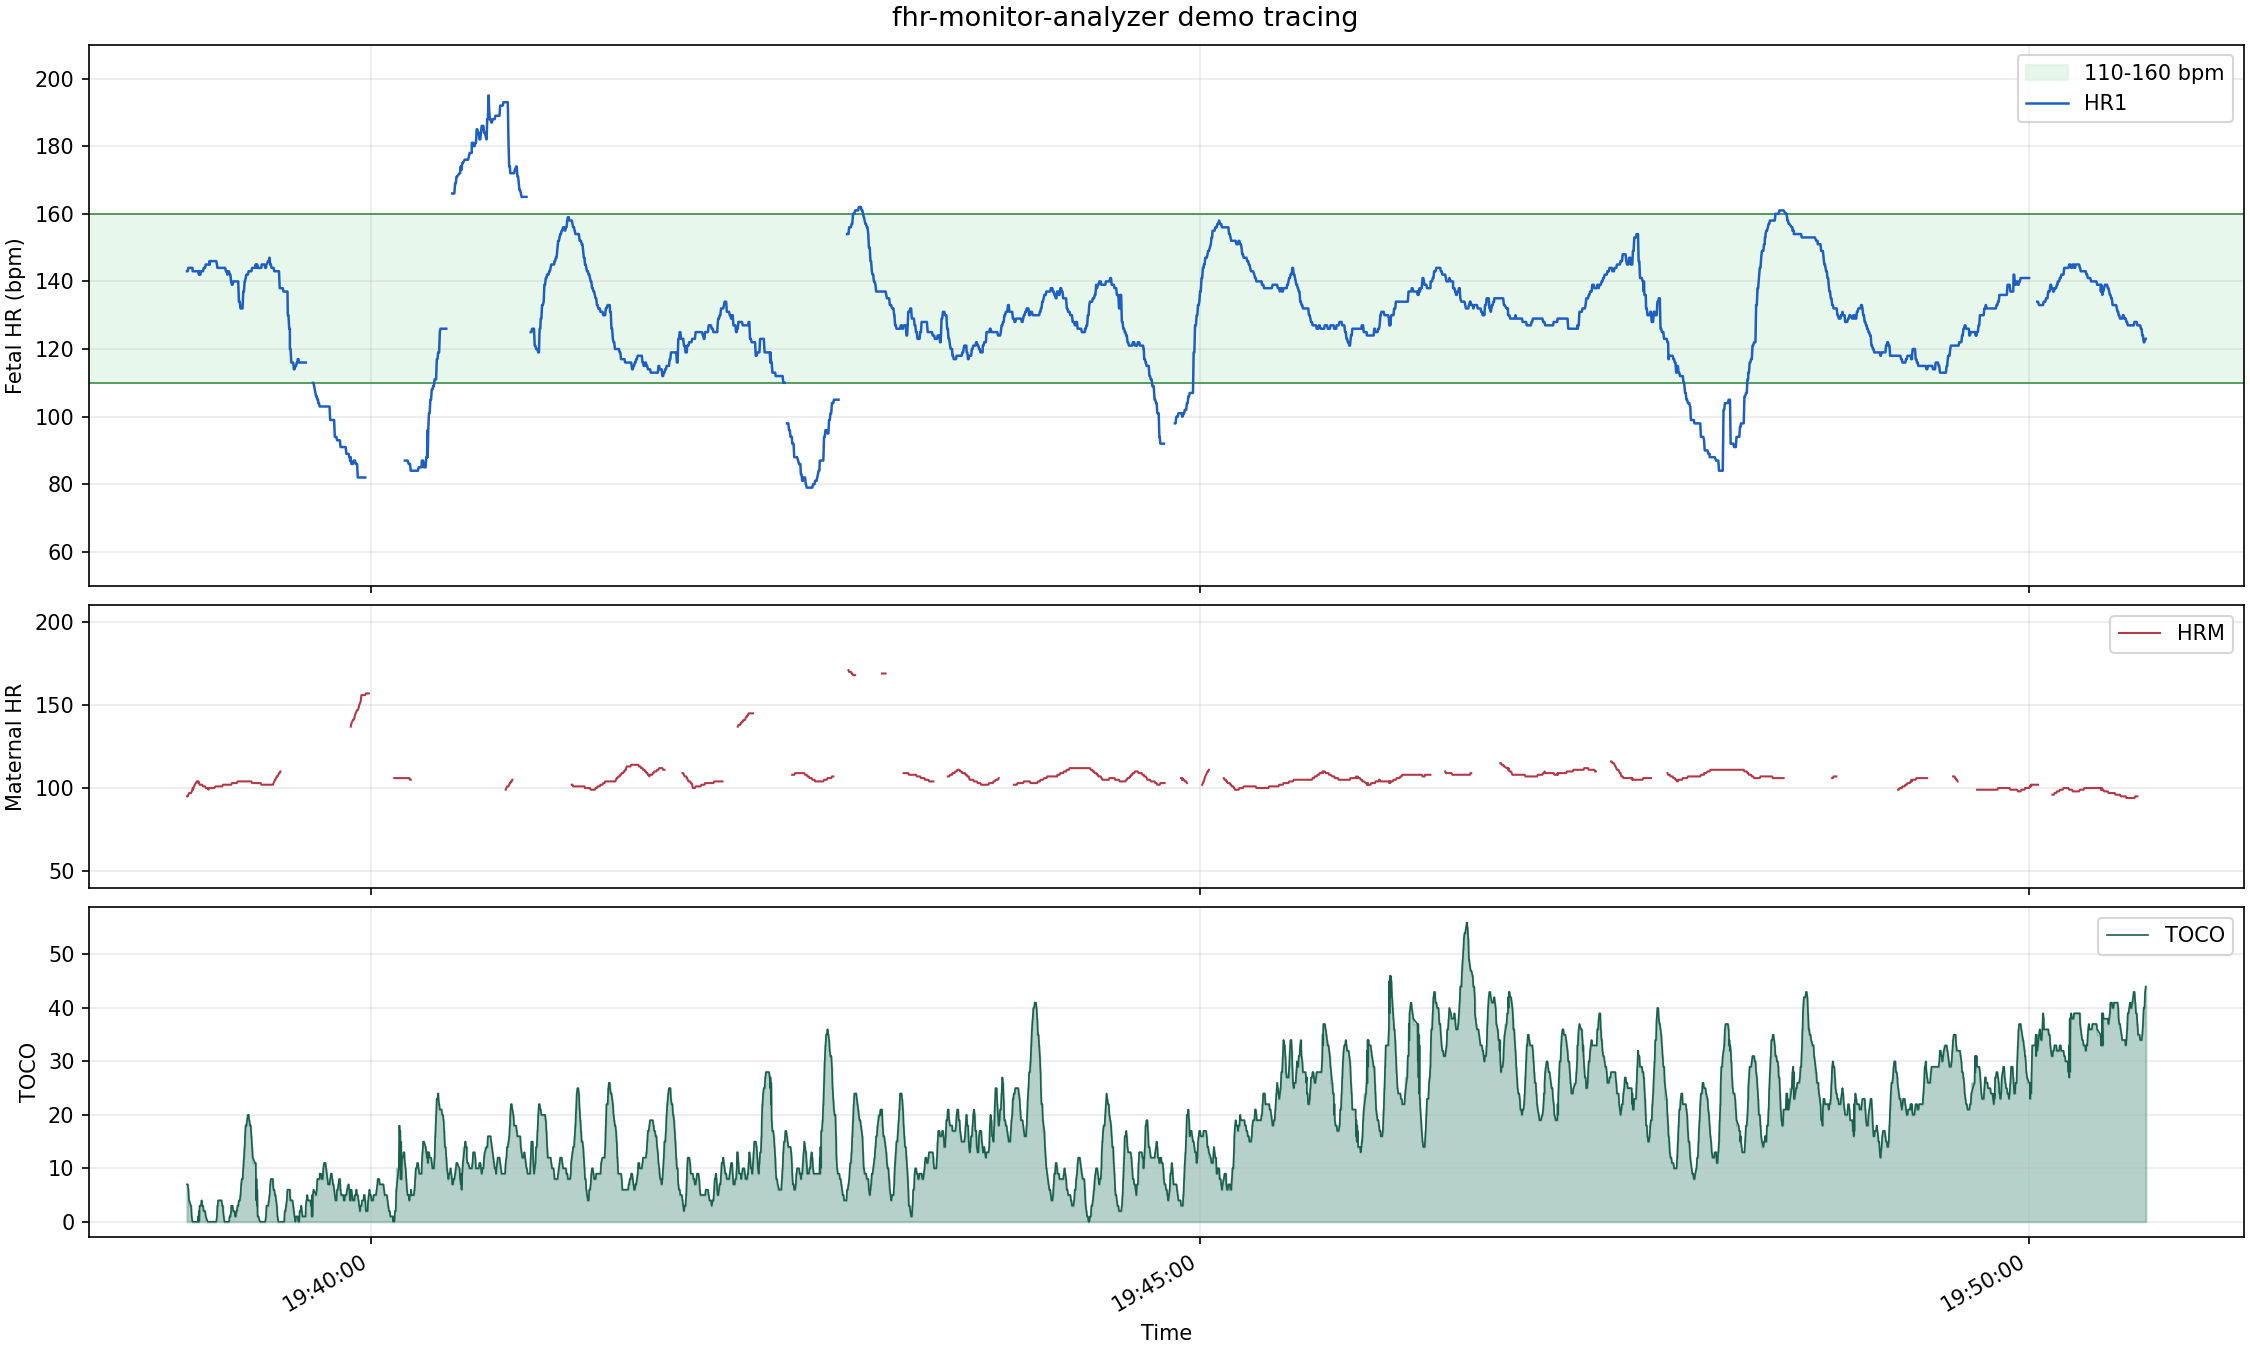

In [12]:
written_plot = analyzer.plot_csv_file(
    csv_path,
    channel="HR1",
    title="fhr-monitor-analyzer demo tracing",
)

display(Image(filename=written_plot))

In [16]:
report_json = analyzer.analyze_csv_file(csv_path, channel="HR1")
report = json.loads(report_json)

#print(json.dumps(report, indent=2))
window = report["windows"][-1]
features = window["features"]

summary = {
    "classification": window["classification"],
    "alert_level": window["alert_level"],
    "baseline_bpm": window["baseline_bpm"],
    "baseline_class": window["baseline_class"],
    "variability_bpm": window["variability_bpm"],
    "variability_class": window["variability_class"],
    "acceleration_count": features["acceleration_count"],
    "deceleration_count": features["deceleration_count"],
    "total_deceleration_seconds": features["total_deceleration_seconds"],
    "contractions_per_10_min": features["contractions_per_10_min"],
    "fetal_usable_ratio": window["data_quality"]["fetal_usable_ratio"],
    "reasons": window["reasons"],
    "high_risk_features": window["high_risk_features"],
    "protective_features": window["protective_features"],
    "limitations": window["limitations"],
}

summary

{'classification': 'category_ii',
 'alert_level': 'urgent_review',
 'baseline_bpm': 130,
 'baseline_class': 'normal',
 'variability_bpm': 19.583,
 'variability_class': 'moderate',
 'acceleration_count': 3,
 'deceleration_count': 4,
 'total_deceleration_seconds': 90.0,
 'contractions_per_10_min': 1.693,
 'fetal_usable_ratio': 0.969,
 'reasons': ['variable deceleration'],
 'high_risk_features': ['deep deceleration nadir below 80 bpm',
  'high deceleration burden: at least 60 seconds in deceleration',
  'recurrent variable decelerations',
  'severe variable deceleration'],
 'protective_features': ['accelerations present', 'moderate variability'],
 'limitations': ['less than 20 minutes: recurrent deceleration assessment is incomplete',
  'less than 30 minutes: tachysystole assessment is incomplete',
  'tachysystole requires a 30-minute contraction average']}